In [2]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load the dengue data
df_dengue_raw = pd.read_csv('../data/raw/dengue_data.csv')

print(f"Shape: {df_dengue_raw.shape}")
print(f"\nColumns: {df_dengue_raw.columns.tolist()}")
print("\nFirst 10 rows:")
df_dengue_raw.head(10)

Shape: (20070, 3)

Columns: ['epi_week', 'disease', 'no._of_cases']

First 10 rows:


,epi_week,disease,no._of_cases
0,2012-W01,Acute Viral hepatitis B,0
1,2012-W01,Acute Viral hepatitis C,0
2,2012-W01,Avian Influenza,0
3,2012-W01,Campylobacterenterosis,6
4,2012-W01,Chikungunya Fever,0
5,2012-W01,Cholera,0
6,2012-W01,Dengue Fever,74
7,2012-W01,Dengue Haemorrhagic Fever,0
8,2012-W01,Diphtheria,0
9,2012-W01,Encephalitis,0


In [4]:
# View all Dengue-related diseases in the dataset
dengue_types = df_dengue_raw[df_dengue_raw['disease'].str.contains('Dengue', case=False, na=False)]['disease'].unique()
print("Dengue types found in dataset:")
print(dengue_types)

# Filter for all Dengue types
df_dengue = df_dengue_raw[df_dengue_raw['disease'].str.contains('Dengue', case=False, na=False)].copy()

print(f"\nFiltered dengue data shape: {df_dengue.shape}")
print("\nFirst 10 rows of dengue data:")
df_dengue.head(10)

Dengue types found in dataset:
['Dengue Fever' 'Dengue Haemorrhagic Fever']

Filtered dengue data shape: (1148, 3)

First 10 rows of dengue data:


,epi_week,disease,no._of_cases
6,2012-W01,Dengue Fever,74
7,2012-W01,Dengue Haemorrhagic Fever,0
37,2012-W02,Dengue Fever,64
38,2012-W02,Dengue Haemorrhagic Fever,2
68,2012-W03,Dengue Fever,60
69,2012-W03,Dengue Haemorrhagic Fever,1
99,2012-W04,Dengue Fever,50
100,2012-W04,Dengue Haemorrhagic Fever,2
130,2012-W05,Dengue Fever,84
131,2012-W05,Dengue Haemorrhagic Fever,1


In [5]:
# Since there is multiple dengue types per week, sum them together
df_dengue_combined = df_dengue.groupby('epi_week').agg({
    'no._of_cases': 'sum'
}).reset_index()

# Rename columns for clarity
df_dengue_combined.columns = ['week_code', 'cases']

print(f"Combined dengue data shape: {df_dengue_combined.shape}")
print(f"\nDate range: {df_dengue_combined['week_code'].min()} to {df_dengue_combined['week_code'].max()}")
print(f"Total weeks: {len(df_dengue_combined)}")
print("\nFirst 10 weeks:")
df_dengue_combined.head(10)

Combined dengue data shape: (574, 2)

Date range: 2012-W01 to 2022-W52
Total weeks: 574

First 10 weeks:


,week_code,cases
0,2012-W01,74
1,2012-W02,66
2,2012-W03,61
3,2012-W04,52
4,2012-W05,85
5,2012-W06,87
6,2012-W07,65
7,2012-W08,51
8,2012-W09,55
9,2012-W10,46


In [6]:
# Convert ISO week format to datetime
def iso_week_to_date(iso_week_string):
    """Convert '2012-W01' format to datetime (Monday of that week)"""
    try:
        # Split into year and week
        year = int(iso_week_string.split('-W')[0])
        week = int(iso_week_string.split('-W')[1])
        
        # Create datetime - %G is ISO year, %V is ISO week, %u is day of week (1=Monday)
        date_str = f'{year}-W{week:02d}-1'
        date = datetime.strptime(date_str, '%G-W%V-%u')
        return date
    except:
        return None

# Apply conversion
df_dengue_combined['date'] = df_dengue_combined['week_code'].apply(iso_week_to_date)

# Sort by date
df_dengue_combined = df_dengue_combined.sort_values('date').reset_index(drop=True)

print("\nFirst 10 rows with dates:")
df_dengue_combined[['week_code', 'date', 'cases']].head(10)


First 10 rows with dates:


,week_code,date,cases
0,2012-W01,2012-01-02,74
1,2012-W02,2012-01-09,66
2,2012-W03,2012-01-16,61
3,2012-W04,2012-01-23,52
4,2012-W05,2012-01-30,85
5,2012-W06,2012-02-06,87
6,2012-W07,2012-02-13,65
7,2012-W08,2012-02-20,51
8,2012-W09,2012-02-27,55
9,2012-W10,2012-03-05,46


In [7]:
# Check for missing values
print("Missing values:")
print(df_dengue_combined.isnull().sum())

# Basic statistics
print("\n" + "="*50)
print("DENGUE CASES STATISTICS")
print("="*50)
print(df_dengue_combined['cases'].describe())

print(f"\nTotal weeks: {len(df_dengue_combined)}")
print(f"Weeks with zero cases: {len(df_dengue_combined[df_dengue_combined['cases'] == 0])}")
print(f"Maximum cases in a week: {df_dengue_combined['cases'].max()}")
print(f"Average cases per week: {df_dengue_combined['cases'].mean():.1f}")

Missing values:
week_code    0
cases        0
date         1
dtype: int64

DENGUE CASES STATISTICS
count     574.000000
mean      286.493031
std       295.941640
min        24.000000
25%        81.250000
50%       210.000000
75%       373.750000
max      1792.000000
Name: cases, dtype: float64

Total weeks: 574
Weeks with zero cases: 0
Maximum cases in a week: 1792
Average cases per week: 286.5


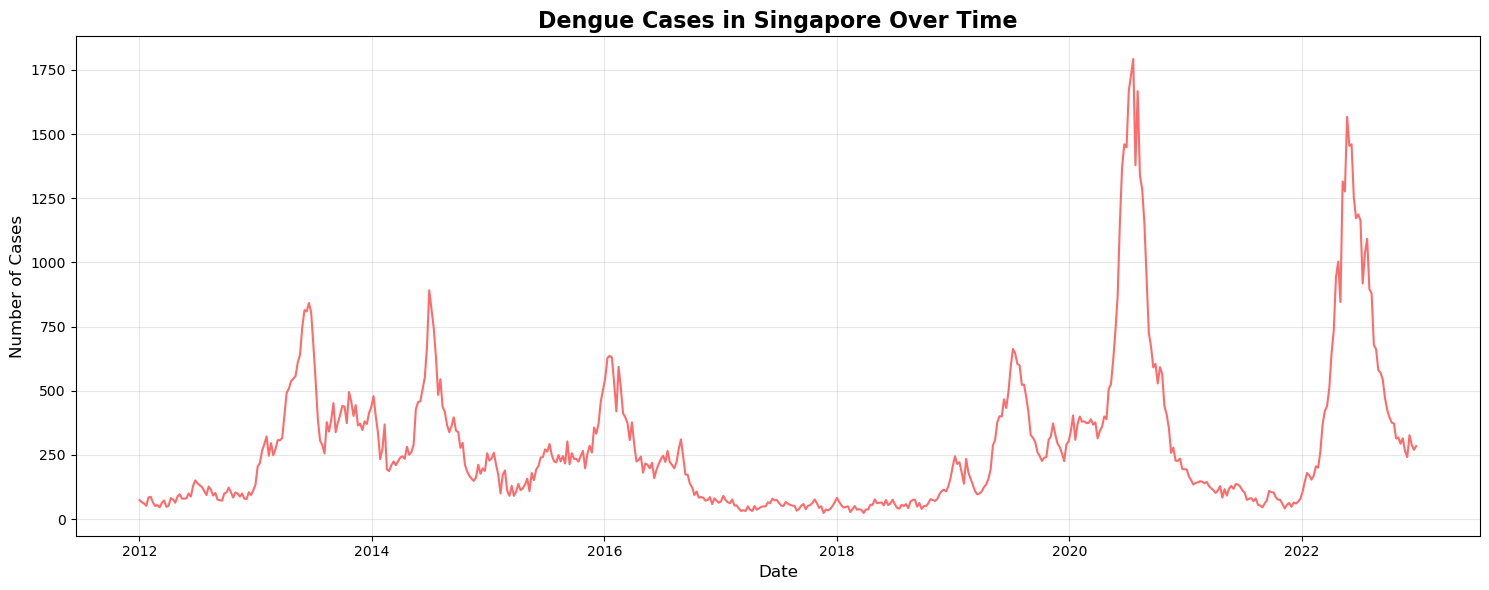

In [8]:
# Create time series plot
plt.figure(figsize=(15, 6))
plt.plot(df_dengue_combined['date'], df_dengue_combined['cases'], 
         linewidth=1.5, color='#FF6B6B')
plt.title('Dengue Cases in Singapore Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Extract time features
df_dengue_combined['year'] = df_dengue_combined['date'].dt.year
df_dengue_combined['month'] = df_dengue_combined['date'].dt.month
df_dengue_combined['week_of_year'] = df_dengue_combined['date'].dt.isocalendar().week
df_dengue_combined['quarter'] = df_dengue_combined['date'].dt.quarter

print("\nDataset now includes:")
print(df_dengue_combined.columns.tolist())
print("\nSample:")
df_dengue_combined[['date', 'year', 'month', 'week_of_year', 'cases']].head()


Dataset now includes:
['week_code', 'cases', 'date', 'year', 'month', 'week_of_year', 'quarter']

Sample:


,date,year,month,week_of_year,cases
0,2012-01-02,2012.0,1.0,1,74
1,2012-01-09,2012.0,1.0,2,66
2,2012-01-16,2012.0,1.0,3,61
3,2012-01-23,2012.0,1.0,4,52
4,2012-01-30,2012.0,1.0,5,85


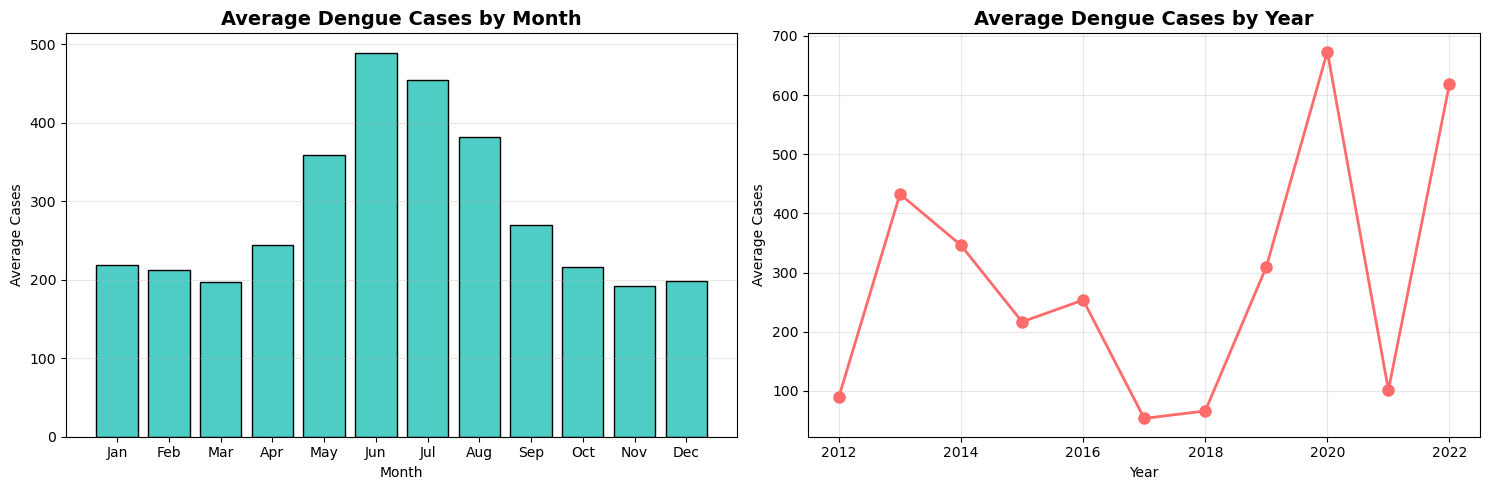

In [10]:
# Monthly average cases
monthly_avg = df_dengue_combined.groupby('month')['cases'].mean()

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Monthly average
axes[0].bar(monthly_avg.index, monthly_avg.values, color='#4ECDC4', edgecolor='black')
axes[0].set_title('Average Dengue Cases by Month', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Cases')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Yearly trend
yearly_avg = df_dengue_combined.groupby('year')['cases'].mean()
axes[1].plot(yearly_avg.index, yearly_avg.values, marker='o', 
             linewidth=2, markersize=8, color='#FF6B6B')
axes[1].set_title('Average Dengue Cases by Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Cases')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Export cleaned dengue data
df_dengue_combined.to_csv('../data/processed/dengue_cleaned.csv', index=False)

In [12]:
# Check the weather data
print("RAINFALL DATA:")
print("="*50)
df_rain = pd.read_csv('../data/raw/rainfall_data.csv')
print(f"Shape: {df_rain.shape}")
print(f"Columns: {df_rain.columns.tolist()}")
print("\nFirst 5 rows:")
print(df_rain.head())

print("\n\nTEMPERATURE DATA:")
print("="*50)
df_temp = pd.read_csv('../data/raw/temperature_data.csv')
print(f"Shape: {df_temp.shape}")
print(f"Columns: {df_temp.columns.tolist()}")
print("\nFirst 5 rows:")
print(df_temp.head())

RAINFALL DATA:
Shape: (529, 2)
Columns: ['month', 'total_rainfall']

First 5 rows:
     month  total_rainfall
0  1982-01           107.1
1  1982-02            27.8
2  1982-03           160.8
3  1982-04           157.0
4  1982-05           102.2


TEMPERATURE DATA:
Shape: (529, 2)
Columns: ['month', 'temp_mean_daily_min']

First 5 rows:
     month  temp_mean_daily_min
0  1982-01                 23.3
1  1982-02                 23.9
2  1982-03                 24.3
3  1982-04                 24.3
4  1982-05                 25.2


In [13]:
# Convert month to datetime
df_rain['month'] = pd.to_datetime(df_rain['month'])

# Rename columns for clarity
df_rain = df_rain.rename(columns={'total_rainfall': 'rainfall'})

# Sort by date
df_rain = df_rain.sort_values('month').reset_index(drop=True)


print(f"Date range: {df_rain['month'].min()} to {df_rain['month'].max()}")
print(f"\nFirst 10 rows:")
print(df_rain.head(10))
print(f"\nBasic stats:")
print(df_rain['rainfall'].describe())

Date range: 1982-01-01 00:00:00 to 2026-01-01 00:00:00

First 10 rows:
       month  rainfall
0 1982-01-01     107.1
1 1982-02-01      27.8
2 1982-03-01     160.8
3 1982-04-01     157.0
4 1982-05-01     102.2
5 1982-06-01      59.5
6 1982-07-01      76.3
7 1982-08-01     169.5
8 1982-09-01      54.1
9 1982-10-01      39.3

Basic stats:
count    529.000000
mean     179.718715
std      114.873322
min        0.200000
25%       96.600000
50%      160.800000
75%      239.600000
max      765.900000
Name: rainfall, dtype: float64


In [14]:
# Convert month to datetime
df_temp['month'] = pd.to_datetime(df_temp['month'])

# Rename columns for clarity
df_temp = df_temp.rename(columns={'temp_mean_daily_min': 'temperature'})

# Sort by date
df_temp = df_temp.sort_values('month').reset_index(drop=True)


print(f"Date range: {df_temp['month'].min()} to {df_temp['month'].max()}")
print(f"\nFirst 10 rows:")
print(df_temp.head(10))
print(f"\nBasic stats:")
print(df_temp['temperature'].describe())

Date range: 1982-01-01 00:00:00 to 2026-01-01 00:00:00

First 10 rows:
       month  temperature
0 1982-01-01         23.3
1 1982-02-01         23.9
2 1982-03-01         24.3
3 1982-04-01         24.3
4 1982-05-01         25.2
5 1982-06-01         26.0
6 1982-07-01         25.5
7 1982-08-01         25.0
8 1982-09-01         25.3
9 1982-10-01         24.3

Basic stats:
count    529.000000
mean      24.968809
std        0.753647
min       22.900000
25%       24.500000
50%       24.900000
75%       25.400000
max       27.100000
Name: temperature, dtype: float64


In [15]:
# Merge rainfall and temperature by month
df_weather = pd.merge(df_rain, df_temp, on='month', how='inner')

print(f"Shape: {df_weather.shape}")
print(f"\nColumns: {df_weather.columns.tolist()}")
print(f"\nFirst 10 rows:")
print(df_weather.head(10))

Weather data merged!
Shape: (529, 3)

Columns: ['month', 'rainfall', 'temperature']

First 10 rows:
       month  rainfall  temperature
0 1982-01-01     107.1         23.3
1 1982-02-01      27.8         23.9
2 1982-03-01     160.8         24.3
3 1982-04-01     157.0         24.3
4 1982-05-01     102.2         25.2
5 1982-06-01      59.5         26.0
6 1982-07-01      76.3         25.5
7 1982-08-01     169.5         25.0
8 1982-09-01      54.1         25.3
9 1982-10-01      39.3         24.3


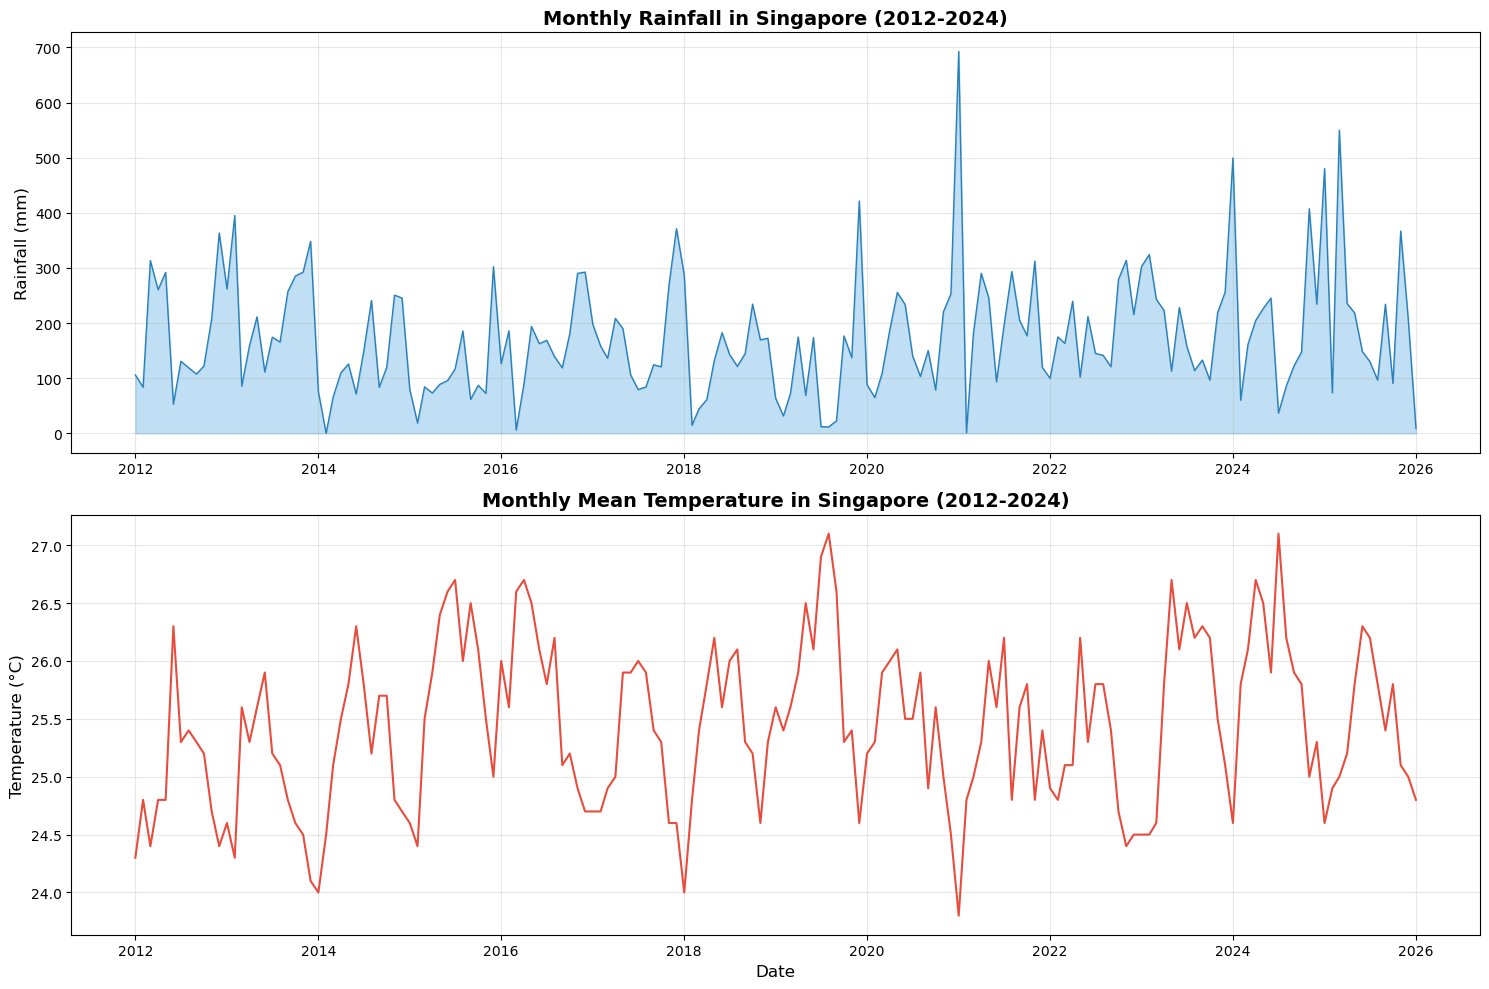

In [16]:
# Create weather visualizations
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Filter to same date range as dengue data (2012 onwards)
df_weather_recent = df_weather[df_weather['month'] >= '2012-01-01']

# Plot 1: Rainfall over time
axes[0].fill_between(df_weather_recent['month'], df_weather_recent['rainfall'], 
                      alpha=0.3, color='#3498db')
axes[0].plot(df_weather_recent['month'], df_weather_recent['rainfall'], 
             linewidth=1, color='#2980b9')
axes[0].set_title('Monthly Rainfall in Singapore (2012-2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Rainfall (mm)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Plot 2: Temperature over time
axes[1].plot(df_weather_recent['month'], df_weather_recent['temperature'], 
             linewidth=1.5, color='#e74c3c')
axes[1].set_title('Monthly Mean Temperature in Singapore (2012-2024)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Temperature (°C)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [17]:
# Export cleaned weather data (rainfall + temperature merged)
df_weather.to_csv('../data/processed/weather_cleaned.csv', index=False)

## Data Summary:
- **Dengue:** Weekly data from 2012-2024 (~600+ weeks)
- **Weather:** Monthly data from 1982-2024 (~500+ months)
- **Challenge for Day 2:** Align weekly dengue with monthly weather!

## Key Insights:
- Dengue shows seasonal patterns (higher in certain months)
- Weather data spans much longer than dengue data
- Both datasets are clean with no missing values